<a href="https://colab.research.google.com/github/Mao925/Predicting-Stellar-Class/blob/main/Predicting_Stellar_Class.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np

# =========================
# 1. データ読み込み
# =========================

train_path = '/content/drive/MyDrive/Playground (1)/train.csv'
test_path = '/content/drive/MyDrive/Playground (1)/test.csv'

train = pd.read_csv(train_path)
test = pd.read_csv(test_path)

print("train shape:", train.shape)
print("test shape :", test.shape)

display(train.head())
display(test.head())


# =========================
# 2. 基本情報
# =========================

print("===== train info =====")
train.info()

print("\n===== test info =====")
test.info()

print("\n===== train describe =====")
display(train.describe(include='all').T)

print("\n===== test describe =====")
display(test.describe(include='all').T)


# =========================
# 3. 欠損値確認
# =========================

def missing_summary(df, name):
    missing = pd.DataFrame({
        "missing_count": df.isnull().sum(),
        "missing_ratio": df.isnull().mean()
    })
    missing = missing[missing["missing_count"] > 0].sort_values("missing_ratio", ascending=False)

    print(f"\n===== {name} missing summary =====")
    if len(missing) == 0:
        print("欠損値なし")
    else:
        display(missing)

missing_summary(train, "train")
missing_summary(test, "test")


# =========================
# 4. カラム・型の確認
# =========================

print("\n===== train dtypes =====")
display(train.dtypes.value_counts())

print("\n===== test dtypes =====")
display(test.dtypes.value_counts())

num_cols = train.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = train.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("数値カラム数:", len(num_cols))
print("カテゴリ系カラム数:", len(cat_cols))

print("\nカテゴリ系カラム:")
print(cat_cols)


# =========================
# 5. 目的変数の自動判定
# trainにあってtestにないカラムを目的変数候補とする
# =========================

target_candidates = [col for col in train.columns if col not in test.columns]

print("\n目的変数候補:", target_candidates)

if len(target_candidates) == 1:
    target_col = target_candidates[0]
    print("目的変数:", target_col)
else:
    # うまく自動判定できない場合はここを手動で変更
    target_col = target_candidates[0] if len(target_candidates) > 0 else None
    print("目的変数を自動で一意に決められません。target_colを手動で指定してください。")

# 例:
# target_col = "Survived"
# target_col = "SalePrice"


# =========================
# 6. 目的変数の分布確認
# =========================

if target_col is not None:
    print("\n===== target distribution =====")
    print(train[target_col].describe())

    if train[target_col].nunique() <= 20:
        display(train[target_col].value_counts().sort_index())
    else:
        display(train[target_col].hist(bins=30))


# =========================
# 7. 目的変数と数値特徴量の関係
# =========================

if target_col is not None:
    feature_cols = [col for col in train.columns if col != target_col]

    numeric_features = train[feature_cols].select_dtypes(include=["int64", "float64"]).columns.tolist()
    categorical_features = train[feature_cols].select_dtypes(include=["object", "category", "bool"]).columns.tolist()

    print("\n===== numeric features =====")
    print(numeric_features)

    print("\n===== categorical features =====")
    print(categorical_features)

    # 数値目的変数の場合：相関を見る
    if pd.api.types.is_numeric_dtype(train[target_col]):
        corr_df = train[numeric_features + [target_col]].corr(numeric_only=True)[target_col] \
            .drop(target_col) \
            .sort_values(key=lambda x: x.abs(), ascending=False)

        print("\n===== 目的変数との相関 上位 =====")
        display(corr_df.head(30).to_frame("corr_with_target"))

    # 分類問題っぽい場合：目的変数別の平均を見る
    if train[target_col].nunique() <= 20:
        print("\n===== 目的変数別の数値特徴量平均 =====")
        display(train.groupby(target_col)[numeric_features].mean().T)


# =========================
# 8. 目的変数とカテゴリ変数の関係
# =========================

if target_col is not None and len(categorical_features) > 0:
    print("\n===== categorical features summary =====")

    for col in categorical_features:
        print(f"\n--- {col} ---")
        print("nunique:", train[col].nunique())
        display(train[col].value_counts(dropna=False).head(20))

        # 目的変数が数値ならカテゴリごとの目的変数平均を見る
        if pd.api.types.is_numeric_dtype(train[target_col]):
            tmp = train.groupby(col, dropna=False)[target_col].agg(["count", "mean"]).sort_values("mean", ascending=False)
            display(tmp.head(20))


# =========================
# 9. XGBoost用の注意：object型の有無
# =========================

object_cols_train = train.select_dtypes(include=["object"]).columns.tolist()
object_cols_test = test.select_dtypes(include=["object"]).columns.tolist()

print("\n===== XGBoost前の注意 =====")
print("train object cols:", object_cols_train)
print("test object cols :", object_cols_test)

if len(object_cols_train) > 0 or len(object_cols_test) > 0:
    print("""
XGBoostは欠損値は扱えますが、object型のカテゴリ変数はそのままだとエラーになることがあります。
使う場合は以下のどちらかが必要です。

1. One-Hot Encodingする
2. category型に変換して enable_categorical=True を使う
""")
else:
    print("object型カラムなし。数値中心なのでXGBoostにそのまま入れやすいです。")

train shape: (577347, 12)
test shape : (247435, 11)


,id,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class
0,0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,M,Red_Sequence,GALAXY
1,1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,M,Red_Sequence,GALAXY
2,2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,O/B,Blue_Cloud,QSO
3,3,225.818295,48.569421,23.305056,21.050736,19.017754,18.365658,17.914952,0.536099,M,Red_Sequence,GALAXY
4,4,141.836135,19.342852,21.703158,19.471680,18.234449,17.899447,17.616185,0.555761,M,Red_Sequence,GALAXY


,id,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population
0,577347,120.719779,23.924249,23.668066,21.951680,21.086183,20.180032,19.202124,0.429042,G/K,Red_Sequence
1,577348,219.414419,42.171651,24.902933,22.338822,20.732163,19.860330,19.687691,0.867305,M,Red_Sequence
2,577349,173.568731,-1.756400,19.427591,18.474633,17.551314,16.570674,16.176765,0.224234,G/K,Blue_Cloud
3,577350,184.903993,-1.411074,23.121029,21.526855,20.670159,20.417633,20.699095,0.066507,G/K,Red_Sequence
4,577351,222.487816,15.381403,25.094282,22.643981,21.123173,19.439500,19.094158,0.977218,M,Red_Sequence


===== train info =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 577347 entries, 0 to 577346
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 577347 non-null  int64  
 1   alpha              577347 non-null  float64
 2   delta              577347 non-null  float64
 3   u                  577347 non-null  float64
 4   g                  577347 non-null  float64
 5   r                  577347 non-null  float64
 6   i                  577347 non-null  float64
 7   z                  577347 non-null  float64
 8   redshift           577347 non-null  float64
 9   spectral_type      577347 non-null  object 
 10  galaxy_population  577347 non-null  object 
 11  class              577347 non-null  object 
dtypes: float64(8), int64(1), object(3)
memory usage: 52.9+ MB

===== test info =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 247435 entries, 0 to 247434
Data columns (to

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,577347.0,NaN,NaN,NaN,288673.0,166665.86727,0.0,144336.5,288673.0,433009.5,577346.0
alpha,577347.0,NaN,NaN,NaN,181.616673,96.242941,0.011684,132.161499,188.681465,231.829693,359.99981
delta,577347.0,NaN,NaN,NaN,21.834654,18.93357,-17.966988,2.474097,21.484412,36.98831,79.158322
u,577347.0,NaN,NaN,NaN,22.441926,2.018135,-0.139225,20.97709,22.570222,23.869103,28.253263
g,577347.0,NaN,NaN,NaN,21.007273,1.795426,13.535483,19.865005,21.46782,22.292715,27.620208
r,577347.0,NaN,NaN,NaN,19.962811,1.648964,12.579407,18.820671,20.431153,21.164096,25.254499
i,577347.0,NaN,NaN,NaN,19.378911,1.580059,11.962781,18.30682,19.631642,20.608191,27.910853
z,577347.0,NaN,NaN,NaN,19.041136,1.584365,11.682803,17.973192,19.188598,20.162111,26.826867
redshift,577347.0,NaN,NaN,NaN,0.723135,0.81007,-0.00997,0.181052,0.497525,0.88139,7.01078
spectral_type,577347,4,M,303323,NaN,NaN,NaN,NaN,NaN,NaN,NaN


...


===== categorical features summary =====

--- spectral_type ---
nunique: 4


,count
spectral_type,
M,303323
A/F,122122
G/K,108546
O/B,43356



--- galaxy_population ---
nunique: 2


,count
galaxy_population,
Red_Sequence,319565
Blue_Cloud,257782



===== XGBoost前の注意 =====
train object cols: ['spectral_type', 'galaxy_population', 'class']
test object cols : ['spectral_type', 'galaxy_population']

XGBoostは欠損値は扱えますが、object型のカテゴリ変数はそのままだとエラーになることがあります。
使う場合は以下のどちらかが必要です。

1. One-Hot Encodingする
2. category型に変換して enable_categorical=True を使う



In [3]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# =========================
# 1. 目的変数・IDカラムの指定
# =========================

target_col = "class"
id_col = "id"

# 提出用にtestのidは保存しておく
test_ids = test[id_col].copy()


# =========================
# 2. X, y, X_test に分ける
# =========================

X = train.drop(columns=[target_col, id_col])
y = train[target_col].copy()

X_test = test.drop(columns=[id_col])


# =========================
# 3. targetを数値化
# classが文字列の場合に備える
# =========================

le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("class mapping:")
for original, encoded in zip(le.classes_, range(len(le.classes_))):
    print(f"{original} -> {encoded}")


# =========================
# 4. object型カラムがある場合だけ処理
# 今回はおそらく特徴量は全部数値なので、基本的には何もしない
# =========================

cat_cols = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("カテゴリ系特徴量:", cat_cols)

if len(cat_cols) > 0:
    # 最低限安全な処理：one-hot encoding
    X = pd.get_dummies(X, columns=cat_cols, dummy_na=True)
    X_test = pd.get_dummies(X_test, columns=cat_cols, dummy_na=True)

    # train/testで列を揃える
    X, X_test = X.align(X_test, join="left", axis=1, fill_value=0)


# =========================
# 5. 最終確認
# =========================

print("X shape:", X.shape)
print("y shape:", y_encoded.shape)
print("X_test shape:", X_test.shape)

print("\nX dtypes:")
print(X.dtypes.value_counts())

print("\n欠損値数:")
print("X:", X.isnull().sum().sum())
print("X_test:", X_test.isnull().sum().sum())

display(X.head())
display(pd.Series(y_encoded, name="class_encoded").head())
display(X_test.head())


# =========================
# 6. 学習用・検証用に分割
# =========================

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("X_train:", X_train.shape)
print("X_valid:", X_valid.shape)
print("y_train:", y_train.shape)
print("y_valid:", y_valid.shape)

class mapping:
GALAXY -> 0
QSO -> 1
STAR -> 2
カテゴリ系特徴量: ['spectral_type', 'galaxy_population']
X shape: (577347, 16)
y shape: (577347,)
X_test shape: (247435, 16)

X dtypes:
float64    8
bool       8
Name: count, dtype: int64

欠損値数:
X: 0
X_test: 0


,alpha,delta,u,g,r,i,z,redshift,spectral_type_A/F,spectral_type_G/K,spectral_type_M,spectral_type_O/B,spectral_type_nan,galaxy_population_Blue_Cloud,galaxy_population_Red_Sequence,galaxy_population_nan
0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,False,False,True,False,False,False,True,False
1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,False,False,True,False,False,False,True,False
2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,False,False,False,True,False,True,False,False
3,225.818295,48.569421,23.305056,21.050736,19.017754,18.365658,17.914952,0.536099,False,False,True,False,False,False,True,False
4,141.836135,19.342852,21.703158,19.471680,18.234449,17.899447,17.616185,0.555761,False,False,True,False,False,False,True,False


,class_encoded
0,0
1,0
2,1
3,0
4,0


,alpha,delta,u,g,r,i,z,redshift,spectral_type_A/F,spectral_type_G/K,spectral_type_M,spectral_type_O/B,spectral_type_nan,galaxy_population_Blue_Cloud,galaxy_population_Red_Sequence,galaxy_population_nan
0,120.719779,23.924249,23.668066,21.951680,21.086183,20.180032,19.202124,0.429042,False,True,False,False,False,False,True,False
1,219.414419,42.171651,24.902933,22.338822,20.732163,19.860330,19.687691,0.867305,False,False,True,False,False,False,True,False
2,173.568731,-1.756400,19.427591,18.474633,17.551314,16.570674,16.176765,0.224234,False,True,False,False,False,True,False,False
3,184.903993,-1.411074,23.121029,21.526855,20.670159,20.417633,20.699095,0.066507,False,True,False,False,False,False,True,False
4,222.487816,15.381403,25.094282,22.643981,21.123173,19.439500,19.094158,0.977218,False,False,True,False,False,False,True,False


X_train: (461877, 16)
X_valid: (115470, 16)
y_train: (461877,)
y_valid: (115470,)


In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, log_loss, classification_report

model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train,
    y_train,
    eval_set=[(X_valid, y_valid)],
    verbose=50
)

valid_pred_proba = model.predict_proba(X_valid)
valid_pred = np.argmax(valid_pred_proba, axis=1)

print("accuracy:", accuracy_score(y_valid, valid_pred))
print("logloss :", log_loss(y_valid, valid_pred_proba))

print(classification_report(y_valid, valid_pred, target_names=le.classes_))

[0]	validation_0-mlogloss:0.82199
[50]	validation_0-mlogloss:0.18627
[100]	validation_0-mlogloss:0.12908
[150]	validation_0-mlogloss:0.11534
[200]	validation_0-mlogloss:0.10893
[250]	validation_0-mlogloss:0.10502
[300]	validation_0-mlogloss:0.10237
[350]	validation_0-mlogloss:0.10038
[400]	validation_0-mlogloss:0.09875
[450]	validation_0-mlogloss:0.09752
[499]	validation_0-mlogloss:0.09649
accuracy: 0.9649172945353771
logloss : 0.0964863843280316
              precision    recall  f1-score   support

      GALAXY       0.97      0.98      0.98     75496
         QSO       0.96      0.96      0.96     23429
        STAR       0.92      0.92      0.92     16545

    accuracy                           0.96    115470
   macro avg       0.95      0.95      0.95    115470
weighted avg       0.96      0.96      0.96    115470



In [ ]:
test_pred_encoded = model.predict(X_test)

# 数値ラベルを元のclass名に戻す
test_pred = le.inverse_transform(test_pred_encoded)

submission = pd.DataFrame({
    "id": test_ids,
    "class": test_pred
})

display(submission.head())

submission.to_csv("/content/drive/MyDrive/Playground (1)/submission_xgb_baseline.csv", index=False)
print("saved!")

,id,class
0,577347,GALAXY
1,577348,GALAXY
2,577349,GALAXY
3,577350,STAR
4,577351,GALAXY


saved!


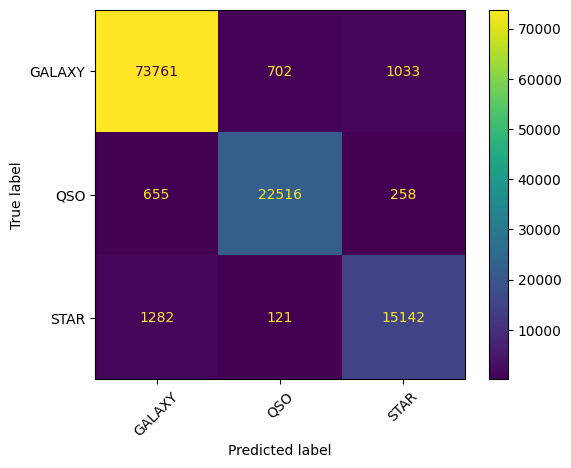

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_valid, valid_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=le.classes_
)

disp.plot(xticks_rotation=45)
plt.show()

In [ ]:
train_pred = model.predict(X_train)
valid_pred = model.predict(X_valid)

print("train accuracy:", accuracy_score(y_train, train_pred))
print("valid accuracy:", accuracy_score(y_valid, valid_pred))

train accuracy: 0.969859941066561
valid accuracy: 0.9649172945353771


In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, log_loss, classification_report

model = XGBClassifier(
    n_estimators=3000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=100,
    tree_method="hist"
)

model.fit(
    X_train,
    y_train,
    eval_set=[(X_valid, y_valid)],
    verbose=100
)

valid_pred_proba = model.predict_proba(X_valid)
valid_pred = np.argmax(valid_pred_proba, axis=1)

print("best_iteration:", model.best_iteration)
print("best_score:", model.best_score)

print("accuracy:", accuracy_score(y_valid, valid_pred))
print("logloss :", log_loss(y_valid, valid_pred_proba))

print(classification_report(y_valid, valid_pred, target_names=le.classes_))

[0]	validation_0-mlogloss:0.82199
[100]	validation_0-mlogloss:0.12908
[200]	validation_0-mlogloss:0.10893
[300]	validation_0-mlogloss:0.10237
[400]	validation_0-mlogloss:0.09875
[500]	validation_0-mlogloss:0.09647
[600]	validation_0-mlogloss:0.09482
[700]	validation_0-mlogloss:0.09372
[800]	validation_0-mlogloss:0.09287
[900]	validation_0-mlogloss:0.09238
[1000]	validation_0-mlogloss:0.09198
[1100]	validation_0-mlogloss:0.09170
[1200]	validation_0-mlogloss:0.09151
[1300]	validation_0-mlogloss:0.09129
[1400]	validation_0-mlogloss:0.09110
[1500]	validation_0-mlogloss:0.09105
[1600]	validation_0-mlogloss:0.09100
[1700]	validation_0-mlogloss:0.09094
[1788]	validation_0-mlogloss:0.09095
best_iteration: 1688
best_score: 0.09093594038820156
accuracy: 0.967298865506192
logloss : 0.09093594039294495
              precision    recall  f1-score   support

      GALAXY       0.98      0.98      0.98     75496
         QSO       0.96      0.96      0.96     23429
        STAR       0.93      0.92  

In [ ]:
train_pred = model.predict(X_train)
valid_pred = model.predict(X_valid)

print("train accuracy:", accuracy_score(y_train, train_pred))
print("valid accuracy:", accuracy_score(y_valid, valid_pred))

train accuracy: 0.980880191046534
valid accuracy: 0.967298865506192


In [ ]:
# =========================
# Early Stopping済みXGBoostで提出ファイル作成
# =========================

import pandas as pd
import numpy as np

# best_iterationを確認
print("best_iteration:", model.best_iteration)
print("best_score:", model.best_score)

# =========================
# 1. testデータを予測
# =========================
# 念のため best_iteration までの木を使って予測
try:
    test_pred_proba = model.predict_proba(
        X_test,
        iteration_range=(0, model.best_iteration + 1)
    )
except TypeError:
    # ColabのXGBoostバージョンによっては iteration_range が使えない場合
    test_pred_proba = model.predict_proba(X_test)

test_pred_encoded = np.argmax(test_pred_proba, axis=1)

# 数値ラベルを元の class 名に戻す
test_pred = le.inverse_transform(test_pred_encoded)

# =========================
# 2. submission作成
# =========================

submission = pd.DataFrame({
    "id": test_ids,
    "class": test_pred
})

display(submission.head())
display(submission["class"].value_counts())
display(submission["class"].value_counts(normalize=True))

# 念のため確認
print("submission shape:", submission.shape)
print("missing:", submission.isnull().sum().sum())

# =========================
# 3. CSV保存
# =========================

save_path = f"/content/drive/MyDrive/Playground (1)/submission_xgb_es_best{model.best_iteration}.csv"

submission.to_csv(save_path, index=False)

print("saved:", save_path)

best_iteration: 1688
best_score: 0.09093594038820156


,id,class
0,577347,GALAXY
1,577348,GALAXY
2,577349,GALAXY
3,577350,STAR
4,577351,GALAXY


,count
class,
GALAXY,162256
QSO,50052
STAR,35127


,proportion
class,
GALAXY,0.655752
QSO,0.202283
STAR,0.141965


submission shape: (247435, 2)
missing: 0
saved: /content/drive/MyDrive/Playground (1)/submission_xgb_es_best1688.csv


In [5]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, log_loss, classification_report
import pandas as pd
import numpy as np
import time

# =========================
# GridSearch対象
# =========================

param_grid = {
    "max_depth": [5, 6, 7, 8]
}

# =========================
# 固定パラメータ
# =========================

base_params = {
    "n_estimators": 3000,
    "learning_rate": 0.05,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "objective": "multi:softprob",
    "eval_metric": "mlogloss",
    "random_state": 42,
    "n_jobs": -1,
    "early_stopping_rounds": 100,
    "tree_method": "hist",
    "device": "cuda"
}

# =========================
# GridSearch
# =========================

results = []

best_model = None
best_params = None
best_valid_acc = -1
best_valid_logloss = np.inf

start_all = time.time()

for max_depth in param_grid["max_depth"]:

        print("=" * 60)
        print(f"Training: max_depth={max_depth}")

        start = time.time()

        model = XGBClassifier(
            **base_params,
            max_depth=max_depth
        )

        model.fit(
            X_train,
            y_train,
            eval_set=[(X_valid, y_valid)],
            verbose=False
        )

        # valid予測
        valid_pred_proba = model.predict_proba(X_valid)
        valid_pred = np.argmax(valid_pred_proba, axis=1)

        valid_acc = accuracy_score(y_valid, valid_pred)
        valid_logloss = log_loss(y_valid, valid_pred_proba)

        # train予測：過学習確認用
        train_pred = model.predict(X_train)
        train_acc = accuracy_score(y_train, train_pred)

        elapsed = time.time() - start

        print(f"train accuracy : {train_acc:.6f}")
        print(f"valid accuracy : {valid_acc:.6f}")
        print(f"valid logloss  : {valid_logloss:.6f}")
        print(f"best_iteration : {model.best_iteration}")
        print(f"best_score     : {model.best_score}")
        print(f"elapsed        : {elapsed:.1f} sec")

        results.append({
            "max_depth": max_depth,
            "train_accuracy": train_acc,
            "valid_accuracy": valid_acc,
            "valid_logloss": valid_logloss,
            "best_iteration": model.best_iteration,
            "best_score": model.best_score,
            "elapsed_sec": elapsed
        })

        # valid accuracyを最優先、同点ならloglossが低い方
        if (
            valid_acc > best_valid_acc
            or
            (valid_acc == best_valid_acc and valid_logloss < best_valid_logloss)
        ):
            best_valid_acc = valid_acc
            best_valid_logloss = valid_logloss
            best_model = model
            best_params = {
                "max_depth": max_depth
            }

end_all = time.time()

# =========================
# 結果一覧
# =========================

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    ["valid_accuracy", "valid_logloss"],
    ascending=[False, True]
).reset_index(drop=True)

display(results_df)

print("=" * 60)
print("Best Params:", best_params)
print("Best Valid Accuracy:", best_valid_acc)
print("Best Valid Logloss :", best_valid_logloss)
print(f"Total elapsed: {(end_all - start_all) / 60:.1f} min")

Training: max_depth=5
train accuracy : 0.978377
valid accuracy : 0.967238
valid logloss  : 0.091053
best_iteration : 2495
best_score     : 0.09105273842421462
elapsed        : 27.9 sec
Training: max_depth=6
train accuracy : 0.980367
valid accuracy : 0.966918
valid logloss  : 0.091214
best_iteration : 1616
best_score     : 0.09121446490912266
elapsed        : 21.8 sec
Training: max_depth=7
train accuracy : 0.983387
valid accuracy : 0.967143
valid logloss  : 0.091064
best_iteration : 1220
best_score     : 0.09106445391989752
elapsed        : 20.6 sec
Training: max_depth=8
train accuracy : 0.985202
valid accuracy : 0.967082
valid logloss  : 0.091254
best_iteration : 879
best_score     : 0.09125447133061058
elapsed        : 19.4 sec


,max_depth,train_accuracy,valid_accuracy,valid_logloss,best_iteration,best_score,elapsed_sec
0,5,0.978377,0.967238,0.091053,2495,0.091053,27.887356
1,7,0.983387,0.967143,0.091064,1220,0.091064,20.636797
2,8,0.985202,0.967082,0.091254,879,0.091254,19.360346
3,6,0.980367,0.966918,0.091214,1616,0.091214,21.835829


Best Params: {'max_depth': 5}
Best Valid Accuracy: 0.9672382436996623
Best Valid Logloss : 0.09105273826511961
Total elapsed: 1.5 min


In [7]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, log_loss, classification_report
import pandas as pd
import numpy as np
import time

# =========================
# GridSearch対象
# =========================

param_grid = {
    "max_depth": [3, 4]
}

# =========================
# 固定パラメータ
# =========================

base_params = {
    "n_estimators": 4000,
    "learning_rate": 0.05,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "objective": "multi:softprob",
    "eval_metric": "mlogloss",
    "random_state": 42,
    "n_jobs": -1,
    "early_stopping_rounds": 100,
    "tree_method": "hist",
    "device": "cuda"
}

# =========================
# GridSearch
# =========================

results = []

best_model = None
best_params = None
best_valid_acc = -1
best_valid_logloss = np.inf

start_all = time.time()

for max_depth in param_grid["max_depth"]:

        print("=" * 60)
        print(f"Training: max_depth={max_depth}")

        start = time.time()

        model = XGBClassifier(
            **base_params,
            max_depth=max_depth
        )

        model.fit(
            X_train,
            y_train,
            eval_set=[(X_valid, y_valid)],
            verbose=False
        )

        # valid予測
        valid_pred_proba = model.predict_proba(X_valid)
        valid_pred = np.argmax(valid_pred_proba, axis=1)

        valid_acc = accuracy_score(y_valid, valid_pred)
        valid_logloss = log_loss(y_valid, valid_pred_proba)

        # train予測：過学習確認用
        train_pred = model.predict(X_train)
        train_acc = accuracy_score(y_train, train_pred)

        elapsed = time.time() - start

        print(f"train accuracy : {train_acc:.6f}")
        print(f"valid accuracy : {valid_acc:.6f}")
        print(f"valid logloss  : {valid_logloss:.6f}")
        print(f"best_iteration : {model.best_iteration}")
        print(f"best_score     : {model.best_score}")
        print(f"elapsed        : {elapsed:.1f} sec")

        results.append({
            "max_depth": max_depth,
            "train_accuracy": train_acc,
            "valid_accuracy": valid_acc,
            "valid_logloss": valid_logloss,
            "best_iteration": model.best_iteration,
            "best_score": model.best_score,
            "elapsed_sec": elapsed
        })

        # valid accuracyを最優先、同点ならloglossが低い方
        if (
            valid_acc > best_valid_acc
            or
            (valid_acc == best_valid_acc and valid_logloss < best_valid_logloss)
        ):
            best_valid_acc = valid_acc
            best_valid_logloss = valid_logloss
            best_model = model
            best_params = {
                "max_depth": max_depth
            }

end_all = time.time()

# =========================
# 結果一覧
# =========================

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    ["valid_accuracy", "valid_logloss"],
    ascending=[False, True]
).reset_index(drop=True)

display(results_df)

print("=" * 60)
print("Best Params:", best_params)
print("Best Valid Accuracy:", best_valid_acc)
print("Best Valid Logloss :", best_valid_logloss)
print(f"Total elapsed: {(end_all - start_all) / 60:.1f} min")

Training: max_depth=3
train accuracy : 0.970098
valid accuracy : 0.965220
valid logloss  : 0.094381
best_iteration : 3997
best_score     : 0.09438128280478923
elapsed        : 31.7 sec
Training: max_depth=4
train accuracy : 0.974632
valid accuracy : 0.966727
valid logloss  : 0.092063
best_iteration : 3436
best_score     : 0.09206277193288594
elapsed        : 31.7 sec


,max_depth,train_accuracy,valid_accuracy,valid_logloss,best_iteration,best_score,elapsed_sec
0,4,0.974632,0.966727,0.092063,3436,0.092063,31.742708
1,3,0.970098,0.965220,0.094381,3997,0.094381,31.681605


Best Params: {'max_depth': 4}
Best Valid Accuracy: 0.9667272884731966
Best Valid Logloss : 0.09206277174872947
Total elapsed: 1.1 min


In [8]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, log_loss, classification_report
import pandas as pd
import numpy as np
import time

# =========================
# max_depth=5 専用モデル
# =========================

model_depth5 = XGBClassifier(
    n_estimators=4000,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=100,
    tree_method="hist",
    device="cuda"
)

start = time.time()

model_depth5.fit(
    X_train,
    y_train,
    eval_set=[(X_valid, y_valid)],
    verbose=100
)

elapsed = time.time() - start

print("elapsed:", elapsed)
print("best_iteration:", model_depth5.best_iteration)
print("best_score:", model_depth5.best_score)


# =========================
# valid評価
# =========================

try:
    valid_pred_proba = model_depth5.predict_proba(
        X_valid,
        iteration_range=(0, model_depth5.best_iteration + 1)
    )
except TypeError:
    valid_pred_proba = model_depth5.predict_proba(X_valid)

valid_pred = np.argmax(valid_pred_proba, axis=1)

try:
    train_pred_proba = model_depth5.predict_proba(
        X_train,
        iteration_range=(0, model_depth5.best_iteration + 1)
    )
except TypeError:
    train_pred_proba = model_depth5.predict_proba(X_train)

train_pred = np.argmax(train_pred_proba, axis=1)

print("train accuracy:", accuracy_score(y_train, train_pred))
print("valid accuracy:", accuracy_score(y_valid, valid_pred))
print("valid logloss :", log_loss(y_valid, valid_pred_proba))

print(classification_report(y_valid, valid_pred, target_names=le.classes_))

[0]	validation_0-mlogloss:0.82348
[100]	validation_0-mlogloss:0.13864
[200]	validation_0-mlogloss:0.11604
[300]	validation_0-mlogloss:0.10778
[400]	validation_0-mlogloss:0.10330
[500]	validation_0-mlogloss:0.10023
[600]	validation_0-mlogloss:0.09826
[700]	validation_0-mlogloss:0.09677
[800]	validation_0-mlogloss:0.09551
[900]	validation_0-mlogloss:0.09461
[1000]	validation_0-mlogloss:0.09401
[1100]	validation_0-mlogloss:0.09348
[1200]	validation_0-mlogloss:0.09300
[1300]	validation_0-mlogloss:0.09263
[1400]	validation_0-mlogloss:0.09232
[1500]	validation_0-mlogloss:0.09211
[1600]	validation_0-mlogloss:0.09188
[1700]	validation_0-mlogloss:0.09168
[1800]	validation_0-mlogloss:0.09156
[1900]	validation_0-mlogloss:0.09144
[2000]	validation_0-mlogloss:0.09134
[2100]	validation_0-mlogloss:0.09123
[2200]	validation_0-mlogloss:0.09118
[2300]	validation_0-mlogloss:0.09114
[2400]	validation_0-mlogloss:0.09107
[2500]	validation_0-mlogloss:0.09106
[2595]	validation_0-mlogloss:0.09111
elapsed: 38.4

In [9]:
# =========================
# max_depth=5モデルで提出ファイル作成
# =========================

try:
    test_pred_proba = model_depth5.predict_proba(
        X_test,
        iteration_range=(0, model_depth5.best_iteration + 1)
    )
except TypeError:
    test_pred_proba = model_depth5.predict_proba(X_test)

test_pred_encoded = np.argmax(test_pred_proba, axis=1)
test_pred = le.inverse_transform(test_pred_encoded)

submission = pd.DataFrame({
    "id": test_ids,
    "class": test_pred
})

display(submission.head())
display(submission["class"].value_counts())
display(submission["class"].value_counts(normalize=True))

print("submission shape:", submission.shape)
print("missing:", submission.isnull().sum().sum())

save_path = (
    f"/content/drive/MyDrive/Playground (1)/submission_xgb_depth5_"
    f"best{model_depth5.best_iteration}.csv"
)

submission.to_csv(save_path, index=False)

print("saved:", save_path)

,id,class
0,577347,GALAXY
1,577348,GALAXY
2,577349,GALAXY
3,577350,STAR
4,577351,GALAXY


,count
class,
GALAXY,162241
QSO,50052
STAR,35142


,proportion
class,
GALAXY,0.655691
QSO,0.202283
STAR,0.142025


submission shape: (247435, 2)
missing: 0
saved: /content/drive/MyDrive/Playground (1)/submission_xgb_depth5_best2495.csv
